# Model building

### Train Test split and initial setup

In [3]:
import pandas as pd


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
import joblib

In [6]:
df=pd.read_csv('cleaned_data.csv')
df=df.set_index(['customerID'])
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
customerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,...,1,0,0,1,0,0,0,0,1,0
5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,0,...,1,0,0,0,1,0,0,0,0,1
3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,...,1,0,0,1,0,0,0,0,0,1
7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,1,0,1,0,0,0
9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,...,1,0,0,1,0,0,0,0,1,0


In [7]:
df.shape

(7043, 41)

In [8]:
#feauture-target building
x=df.drop(columns=['Churn'])
y=df['Churn']

print(x.shape,y.shape)

(7043, 40) (7043,)


In [9]:
#train-test split; stratify=y ensures equal percentage of customers are present in train and test data since the churn column is found to be imbalanced earlier
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)
x_test.to_excel('Test dataset.xlsx')

(5634, 40) (1409, 40) (5634,) (1409,)


In [10]:
joblib.dump(list(x_train.columns),"ml_models/columns.pkl")

['ml_models/columns.pkl']

### Scaling Data

In [11]:
from sklearn.preprocessing import StandardScaler

scale=StandardScaler()

x_train_scaled=scale.fit_transform(x_train)
x_test_scaled=scale.transform(x_test)

In [12]:


joblib.dump(scale,"ml_models/scaler.pkl")

['ml_models/scaler.pkl']

### Building logistic regression(base) model

In [13]:
from sklearn.linear_model import LogisticRegression



In [14]:
#build model
model1=LogisticRegression(max_iter=10000)
model1.fit(x_train_scaled,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

In [15]:
#predict using model
y_pred1=model1.predict(x_test_scaled)

In [16]:
#accuracy finding
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred1))

0.8069552874378992


In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



<b><p style="color:red">The model misses 44% of churnd customers(recall for 1 is 0.56).<br>
This may be due to imbalance in data</p></b>

In [18]:
model0=LogisticRegression()
model0.fit(x_train_scaled,y_train)
y_pred0=model0.predict(x_test_scaled)
print(accuracy_score(y_test,y_pred0))
print(classification_report(y_test,y_pred0))

0.8069552874378992
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



##### Model which manages imbalanced data using class_weight=balanced

In [19]:
model2=LogisticRegression(max_iter=10000,class_weight='balanced',)
model2.fit(x_train_scaled,y_train)
y_pred2=model2.predict(x_test_scaled)
print(accuracy_score(y_test,y_pred2))
print(classification_report(y_test,y_pred2))


0.7402413058907026
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



<b><p style="color:green">recall increased from 0.56 to 0.79 which means model now misses only 21% of customers who churn</p>
<p style="color:red">But the model's precision for churn=1 and recall value for churn=0 is decreased so much</p></b>

#### Finding probailities

In [20]:
#finding raw score  - dailed attempt trying to see probability
raw_score=model2.decision_function(x_test_scaled)
print(raw_score)

[-2.00918129  1.75121739 -1.81171808 ... -0.68762742 -4.32271229
 -4.03035709]


In [21]:
#print probabilities
probability=model2.predict_proba(x_test_scaled)
print(probability)

[[0.88175769 0.11824231]
 [0.14789372 0.85210628]
 [0.85956939 0.14043061]
 ...
 [0.66543893 0.33456107]
 [0.98690977 0.01309023]
 [0.98254221 0.01745779]]


In [22]:
#see only churn ptobability
probability[:,1]

array([0.11824231, 0.85210628, 0.14043061, ..., 0.33456107, 0.01309023,
       0.01745779], shape=(1409,))

### Convert probailities into churn 0/1 with manual threshold

In [23]:
y_pred_manualThreshold=((probability[:,1]>0.65).astype(int))

In [24]:
print(accuracy_score(y_test,y_pred_manualThreshold))
print(classification_report(y_test,y_pred_manualThreshold))

0.7750177430801988
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.66      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



### Precision-Recall curve

In [25]:
from sklearn.metrics import precision_recall_curve

precision,recall,threshold=precision_recall_curve(y_test,probability[:,1])

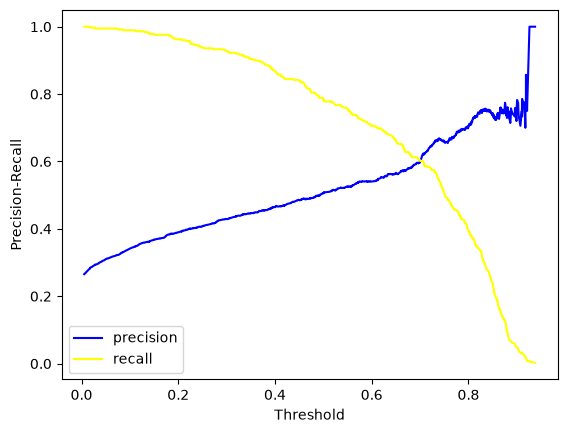

In [26]:
import matplotlib.pyplot as plt

fig,ax=plt.subplots()

ax.plot(threshold,precision[:-1],color='blue',label='precision')
ax.plot(threshold,recall[:-1],color='yellow',label='recall')

ax.set_xlabel('Threshold')
ax.set_ylabel('Precision-Recall')
ax.legend()

plt.show()

## Decision Treee Classifier Model

In [27]:
from sklearn.tree import DecisionTreeClassifier

In [28]:
DTmodel1=DecisionTreeClassifier()
DTmodel1.fit(x_train_scaled,y_train)
y_pred_dt2=DTmodel1.predict(x_test_scaled)
print(accuracy_score(y_test,y_pred_dt2))
print(classification_report(y_test,y_pred_dt2))

0.7217885024840313
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1035
           1       0.48      0.50      0.49       374

    accuracy                           0.72      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.72      0.72      1409



In [29]:
DTmodel2=DecisionTreeClassifier(class_weight='balanced')
DTmodel2.fit(x_train_scaled,y_train)
y_pred_DT2=DTmodel2.predict(x_test_scaled)
print(accuracy_score(y_test,y_pred_DT2))
print(classification_report(y_test,y_pred_DT2))

0.7366926898509581
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1035
           1       0.50      0.49      0.50       374

    accuracy                           0.74      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409



In [30]:
#stop overfitting with max_depth
DTmodel3=DecisionTreeClassifier(class_weight='balanced',max_depth=5)
DTmodel3.fit(x_train_scaled,y_train)
y_pred_DT3=DTmodel3.predict(x_test_scaled)
print(accuracy_score(y_test,y_pred_DT3))
print(classification_report(y_test,y_pred_DT3))

0.7544357700496807
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409



## Random Forest Model

In [31]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
RFmodel1=RandomForestClassifier()
RFmodel1.fit(x_train_scaled,y_train)
y_pred_RF1=RFmodel1.predict(x_test_scaled)
print(accuracy_score(y_test,y_pred_RF1))
print(classification_report(y_test,y_pred_RF1))

0.7835344215755855
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [33]:
RFmodel2=RandomForestClassifier(class_weight='balanced')
RFmodel2.fit(x_train_scaled,y_train)
y_pred_RF2=RFmodel2.predict(x_test_scaled)
print(accuracy_score(y_test,y_pred_RF2))
print(classification_report(y_test,y_pred_RF2))

0.7601135557132718
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1035
           1       0.54      0.62      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.76      0.76      1409



In [34]:
RFmodel3=RandomForestClassifier(class_weight='balanced',max_depth=5)
RFmodel3.fit(x_train_scaled,y_train)
y_pred_RF3=RFmodel3.predict(x_test_scaled)
print(accuracy_score(y_test,y_pred_RF3))
print(classification_report(y_test,y_pred_RF3))

0.7324343506032647
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.80      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409



## Model compaisions

In [35]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [36]:
baseline_models={
    "LogisticRegression (Raw)":y_pred0,
    "LogisticRegression (iter=10000)":y_pred1,
    "LogisticRegression (Balanced+iter=10000)":y_pred2,

    "DecisionTree (Raw)":y_pred_dt2,
    "DecisionTree (balanced)":y_pred_DT2,
    "DecisionTree (balanced+depth=5)":y_pred_DT3,

    "RandomForest (Raw)":y_pred_RF1,
    "RandomForest (balanced)":y_pred_RF2,
    "RandomForest (balanced+depth=5)":y_pred_RF3
}

In [37]:
baseline_data=[]
for model,predictions in baseline_models.items():
    baseline_data.append({
        "Model Configuration":model,
        "Accuracy":accuracy_score(y_test,predictions),
        "Churn Precision":precision_score(y_test,predictions,pos_label=1),
        "Churn Recall":recall_score(y_test,predictions,pos_label=1),
        "Churn F1 score":f1_score(y_test,predictions,pos_label=1)
    })

In [38]:
analysisDF=pd.DataFrame(baseline_data)
analysisDF.to_excel('Model comaprision.xlsx',sheet_name='Base Model Comparision',index=False)

<b><p style="color:blue">
Defensive model:Logistic Regression (Depth=10000)<br>
Agressive model:RandomForest(balanced+depth=5)<br>
Accurate model:DecisionTree(balanced+depth=5)<br>
</p></b>

<b><p style="color:red">But all models are so close and hence can't completely decide before hypertuning. So hypertune first  commit later</p></b>

## Hyper Tuning models


##### Creating scoring parameters


In [138]:
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

In [139]:
churn_precision_scorer = make_scorer(precision_score, pos_label=1, average='binary', zero_division=0)
churn_recall_scorer = make_scorer(recall_score, pos_label=1, average='binary', zero_division=0)
churn_f1_scorer = make_scorer(f1_score, pos_label=1, average='binary', zero_division=0)

### Loging best model results

In [140]:
import openpyxl
import numpy as np

In [141]:
file='Model comaprision.xlsx'
sheet='Hyper Tuned model comparision'

In [142]:
workbook=openpyxl.load_workbook(file)
worksheet=workbook.create_sheet(title=sheet)
header_row=['Model Name','Stratergy','Parameter Concerned','Best Value for Parameters','Best Score']
worksheet.append(header_row)
workbook.save(file)
workbook.close()

In [143]:
def append_model_results(name,stratergy,param,score):
    if stratergy=="Accuracy":
        pc="F1 Score"
    elif stratergy=="Aggressive":
        pc="Recall"
    elif stratergy=="Defensive":
        pc="Precision"
    else:
        print("Invalid Stratergy")
        return
    
    wb=openpyxl.load_workbook(file)
    ws=wb[sheet]

    found_match = False
    for row in ws.iter_rows(min_row=2, max_col=5):
        row_name = row[0].value     
        row_stratergy = row[1].value 

        if row_name == name and row_stratergy == stratergy:
            found_match = True
            existing_score = row[4].value 

            if existing_score is None or score > existing_score:       
                row[3].value = param
                row[4].value = score     
                print(f"Updated existing row for {name} ({stratergy}) because score improved from {existing_score} to {score}.")
            else:
                print(f"Kept existing entry for {name} ({stratergy}). New score ({score}) wasn't higher than {existing_score}.")
            break
            
    if not found_match:
        ws.append([name,stratergy,pc,param,score])

    wb.save(file)
    wb.close()

    print("Appended Successfully")

### Logistic Regression Tuning

In [144]:
from sklearn.model_selection import GridSearchCV

In [145]:
coarse_LR_grid={'C':[0.001,0.01,0.1,1,10,100]}

#### Raw

##### Accuracy Model

In [146]:
grid_lr_raw_f1=GridSearchCV(
    estimator=model0,
    param_grid=coarse_LR_grid,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)

In [147]:
grid_lr_raw_f1.fit(x_train_scaled,y_train)
print("Best C value for F1 in raw logistic regression: ", grid_lr_raw_f1.best_params_['C'])

Best C value for F1 in raw logistic regression:  100


<b><p style="color:red">The best value may be beyond 100</p></b>

In [148]:
coarse_LR_grid_high={'C':[100,1000,10000,100000,1000000]}


In [149]:
grid_lr_raw_f1_highC=GridSearchCV(
    estimator=model0,
    param_grid=coarse_LR_grid_high,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)

In [150]:
grid_lr_raw_f1_highC.fit(x_train_scaled,y_train)
print("Best C value high for F1 in raw logistic regression: ", grid_lr_raw_f1_highC.best_params_['C'])

Best C value high for F1 in raw logistic regression:  1000


<b><p style='color:green'>Best value must be between 101 and 9999</p></b>

In [151]:
coarse_LR_raw_f1_range1={'C':[1000,2000,3000,4000,5000,6000,7000,8000,9000]}
grid_lr_raw_f1_range1=GridSearchCV(
    estimator=model0,
    param_grid=coarse_LR_raw_f1_range1,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_raw_f1_range1.fit(x_train_scaled,y_train)
print("Best C value high for F1 in raw logistic regression: ", grid_lr_raw_f1_range1.best_params_['C'])

Best C value high for F1 in raw logistic regression:  1000


In [152]:
l2=[]
for i in range(100,2000,100):
    l2.append(i)
coarse_LR_raw_f1_range2={'C':l2}
grid_lr_raw_f1_range2=GridSearchCV(
    estimator=model0,
    param_grid=coarse_LR_raw_f1_range2,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_raw_f1_range2.fit(x_train_scaled,y_train)
print("Best C value high for F1 in raw logistic regression: ", grid_lr_raw_f1_range2.best_params_['C'])

Best C value high for F1 in raw logistic regression:  200


In [153]:
l3=[]
for i in range(100,300,10):
    l3.append(i)
coarse_LR_raw_f1_range3={'C':l3}
grid_lr_raw_f1_range3=GridSearchCV(
    estimator=model0,
    param_grid=coarse_LR_raw_f1_range3,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_raw_f1_range3.fit(x_train_scaled,y_train)
print("Best C value high for F1 in raw logistic regression: ", grid_lr_raw_f1_range3.best_params_['C'])

Best C value high for F1 in raw logistic regression:  180


In [154]:
l4=[]
for i in range(171,190):
    l4.append(i)
coarse_LR_raw_f1_range4={'C':l4}
grid_lr_raw_f1_range4=GridSearchCV(
    estimator=model0,
    param_grid=coarse_LR_raw_f1_range4,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_raw_f1_range4.fit(x_train_scaled,y_train)
print("Best C value high for F1 in raw logistic regression: ", grid_lr_raw_f1_range4.best_params_['C'])
print("Best F1 score for raw logistic regression: ", grid_lr_raw_f1_range4.best_score_)

append_model_results("Logistic Regression - Raw",'Accuracy',f"C={grid_lr_raw_f1_range4.best_params_['C']}",grid_lr_raw_f1_range4.best_score_)

Best C value high for F1 in raw logistic regression:  174
Best F1 score for raw logistic regression:  0.5991638501517492
Kept existing entry for Logistic Regression - Raw (Accuracy). New score (0.5991638501517492) wasn't higher than 0.5991638501517492.
Appended Successfully


<big><b><p style='color:blue;'>Best C value for F1 score optimization on Raw LR is 174</p></b></big>

##### Aggressive model (High Recall)

In [155]:
grid_lr_raw_recall=GridSearchCV(
    estimator=model0,
    param_grid=coarse_LR_grid,
    scoring=churn_recall_scorer,
    cv=5,
    n_jobs=-1
)

In [156]:
grid_lr_raw_recall.fit(x_train_scaled,y_train)
print("Best C value for recall in logistic regression",grid_lr_raw_recall.best_params_['C'])


Best C value for recall in logistic regression 1


<b><p style="color:green">Best C value must be between 0.1 and 10</p></b>

In [157]:
coarse_grid_lr_recall_range1={'C':[0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,2,3,4,5,6,7,8,9]}
grid_lr_raw_recall_range1=GridSearchCV(
    estimator=model0,
    param_grid=coarse_grid_lr_recall_range1,
    scoring=churn_recall_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_raw_recall_range1.fit(x_train_scaled,y_train)
print("Best C value for recall in logistic regression",grid_lr_raw_recall_range1.best_params_['C'])

Best C value for recall in logistic regression 0.9


<b><p style="color:green">Best C value must be between 0.801 and 0.999</p></b>

In [158]:
coarse_grid_lr_recall_range2={'C':np.arange(0.801,0.999,0.001)}

grid_lr_raw_recall_range2=grid_lr_raw_recall_range1=GridSearchCV(
    estimator=model0,
    param_grid=coarse_grid_lr_recall_range2,
    scoring=churn_recall_scorer,
    cv=5,
    n_jobs=-1
)

grid_lr_raw_recall_range2.fit(x_train_scaled,y_train)
print("Best C value for recall in logistic regression is {} with recall {}".format(grid_lr_raw_recall_range2.best_params_['C'],grid_lr_raw_recall_range2.best_score_))
append_model_results("Logistic Regression - Raw",'Aggressive',f"C={grid_lr_raw_recall_range2.best_params_['C']}",grid_lr_raw_recall_range2.best_score_)

Best C value for recall in logistic regression is 0.8810000000000001 with recall 0.5491638795986622
Kept existing entry for Logistic Regression - Raw (Aggressive). New score (0.5491638795986622) wasn't higher than 0.5491638795986622.
Appended Successfully


##### Defensive Model - Logistic Regression

In [159]:
grid_lr_raw_precision=GridSearchCV(
    estimator=model0,
    param_grid=coarse_LR_grid,
    scoring=churn_precision_scorer,
    cv=5,
    n_jobs=-1
)

In [160]:
grid_lr_raw_precision.fit(x_train_scaled,y_train)
print(grid_lr_raw_precision.best_params_['C'])

0.001


<b><p style="color:red">Best value may be further smaller</p></ba>

In [161]:
coarse_LR_grid_low={'C':[0.001,0.0001,0.00001,0.000001]}

In [162]:
grid_lr_raw_precision_range1=GridSearchCV(
    estimator=model0,
    param_grid=coarse_LR_grid_low,
    scoring=churn_precision_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_raw_precision_range1.fit(x_train_scaled,y_train)
print(grid_lr_raw_precision_range1.best_params_['C'])


0.001


<b><p style="color:green">Best value between 0.0002 and 0.009</p></b>

In [163]:
coarse_LR_raw_precision_range2={'C':np.arange(0.0002,0.01,0.0001)}

In [164]:
grid_lr_raw_precision_range2=GridSearchCV(
    estimator=model0,
    param_grid=coarse_LR_raw_precision_range2,
    scoring=churn_precision_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_raw_precision_range2.fit(x_train_scaled,y_train)
print(f"Best C value for defensive strategy is {grid_lr_raw_precision_range2.best_params_['C']} with Precision {grid_lr_raw_precision_range2.best_score_}")
append_model_results("Logistic Regression-Raw","Defensive",f"C={grid_lr_raw_precision_range2.best_params_['C']}",grid_lr_raw_precision_range2.best_score_)


Best C value for defensive strategy is 0.0002 with Precision 0.96
Kept existing entry for Logistic Regression-Raw (Defensive). New score (0.96) wasn't higher than 0.96.
Appended Successfully


#### iter=10000

##### Accuracy model

In [165]:
grid_lr_iter_f1=GridSearchCV(
    estimator=LogisticRegression(max_iter=10000),
    param_grid=coarse_LR_grid,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_f1.fit(x_train_scaled,y_train)
print(grid_lr_iter_f1.best_params_['C'])

100


<b><p style="color:blue">Best value between 11 and 999</p></b>

In [166]:
coarse_grid_lr_iter_f1_range1={'C':np.arange(11,1000,1)}

In [167]:
grid_lr_iter_f1_range1=GridSearchCV(
    estimator=LogisticRegression(max_iter=10000),
    param_grid=coarse_grid_lr_iter_f1_range1,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_f1_range1.fit(x_train_scaled,y_train)
print(grid_lr_iter_f1_range1.best_params_['C'])

60


In [168]:
coarse_grid_lr_iter_f1_range2={'C':np.arange(59.1,61.0,0.1)}

In [169]:
grid_lr_iter_f1_range2=GridSearchCV(
    estimator=LogisticRegression(max_iter=10000),
    param_grid=coarse_grid_lr_iter_f1_range2,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_f1_range2.fit(x_train_scaled,y_train)
print(f"The best vale of C for Accuracy Strategy in Logistic Regression with max-Iter=10000 is {grid_lr_iter_f1_range2.best_params_['C']} with f1 score {grid_lr_iter_f1_range2.best_score_}")
append_model_results("Logistic Regression-iter=10000","Accuracy",f"C={grid_lr_iter_f1_range2.best_params_['C']}",grid_lr_iter_f1_range2.best_score_)

The best vale of C for Accuracy Strategy in Logistic Regression with max-Iter=10000 is 59.1 with f1 score 0.5992508652174994
Kept existing entry for Logistic Regression-iter=10000 (Accuracy). New score (0.5992508652174994) wasn't higher than 0.5992508652174994.
Appended Successfully


##### Aggressive Strategy

In [170]:
grid_lr_iter_recall=GridSearchCV(
    estimator=LogisticRegression(max_iter=10000),
    param_grid=coarse_LR_grid,
    scoring=churn_recall_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_recall.fit(x_train_scaled,y_train)
print(grid_lr_iter_recall.best_params_['C'])

1


<b><p style="color:green">Best value between 0.101 and 1.999</p></b>

In [171]:
coarse_grid_lr_iter_recall_range1={'C':np.arange(0.2,2,0.1)}

In [172]:
grid_lr_iter_recall_range1=GridSearchCV(
    estimator=LogisticRegression(max_iter=10000),
    param_grid=coarse_grid_lr_iter_recall_range1,
    scoring=churn_recall_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_recall_range1.fit(x_train_scaled,y_train)
print(grid_lr_iter_recall_range1.best_params_['C'])

0.9000000000000001


<b><p style="color:red">Best value between 0.81 and 0.99</p></b>

In [173]:
coarse_grid_lr_iter_recall_range2={'C':np.arange(0.81,1,0.01)}

In [174]:
grid_lr_iter_recall_range2=GridSearchCV(
    estimator=LogisticRegression(max_iter=10000),
    param_grid=coarse_grid_lr_iter_recall_range2,
    scoring=churn_recall_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_recall_range2.fit(x_train_scaled,y_train)
print(grid_lr_iter_recall_range2.best_params_['C'])

0.8900000000000001


<b><p style="color:green">Best value between 0.881 and 0.899</p></b>

In [175]:
coarse_grid_lr_iter_recall_range3={'C':np.arange(0.881,0.9,0.001)}
grid_lr_iter_recall_range3=GridSearchCV(
    estimator=LogisticRegression(max_iter=10000),
    param_grid=coarse_grid_lr_iter_recall_range3,
    scoring=churn_recall_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_recall_range3.fit(x_train_scaled,y_train)
print(f"Best value for C for Aggressive stratergy in Logistic Regression with max_iter=10000 is {grid_lr_iter_recall_range3.best_params_['C']} with score {grid_lr_iter_recall_range3.best_score_}")
append_model_results("Logistic Regression - iter=10000","Aggressive",f"C={grid_lr_iter_recall_range3.best_params_['C']}",grid_lr_iter_recall_range3.best_score_)

Best value for C for Aggressive stratergy in Logistic Regression with max_iter=10000 is 0.881 with score 0.5491638795986622
Kept existing entry for Logistic Regression - iter=10000 (Aggressive). New score (0.5491638795986622) wasn't higher than 0.5491638795986622.
Appended Successfully


##### Defensive Model

In [176]:
grid_lr_iter_precision=GridSearchCV(
    estimator=LogisticRegression(max_iter=10000),
    param_grid=coarse_LR_grid,
    scoring=churn_precision_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_precision.fit(x_train_scaled,y_train)
print(grid_lr_iter_precision.best_params_['C'])

0.001


<b><p style="color:red">Best value may be further low</p></b> 

In [177]:
grid_lr_iter_precision1=GridSearchCV(
    estimator=LogisticRegression(max_iter=10000),
    param_grid=coarse_LR_grid_low,
    scoring=churn_precision_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_precision1.fit(x_train_scaled,y_train)
print(grid_lr_iter_precision1.best_params_['C'])

0.001


<b><P style="color:green">Best value between 0.0002 and 0.009</p></b>

In [178]:
coarse_grid_lr_iter_range1={'C':np.arange(0.001,0.01,0.001)}
grid_lr_iter_precision2=GridSearchCV(
    estimator=LogisticRegression(max_iter=10000),
    param_grid=coarse_grid_lr_iter_range1,
    scoring=churn_precision_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_precision2.fit(x_train_scaled,y_train)
print(grid_lr_iter_precision2.best_params_['C'])

0.001


<b><P style="color:green">Best value between 0.0002 and 0.0019</p></b>

In [179]:
coarse_grid_lr_iter_range2={'C':np.arange(0.0002,0.002,0.0001)}
grid_lr_iter_precision3=GridSearchCV(
    estimator=LogisticRegression(max_iter=10000),
    param_grid=coarse_grid_lr_iter_range2,
    scoring=churn_precision_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_precision3.fit(x_train_scaled,y_train)
print(f"Best C value for Defensive Strategy in Logistic Regression with iter=10000 is {grid_lr_iter_precision3.best_params_['C']} with precision {grid_lr_iter_precision3.best_score_}")
append_model_results("Logistic Regression- iter=10000","Defensive",f"C={grid_lr_iter_precision3.best_params_['C']}",grid_lr_iter_precision3.best_score_)

Best C value for Defensive Strategy in Logistic Regression with iter=10000 is 0.0002 with precision 0.96
Kept existing entry for Logistic Regression- iter=10000 (Defensive). New score (0.96) wasn't higher than 0.96.
Appended Successfully


#### Balanced + iter

##### Accuracy Model

In [180]:
grid_lr_iter_balanced_f1_1=GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced',max_iter=10000),
    param_grid=coarse_LR_grid,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_balanced_f1_1.fit(x_train_scaled,y_train)
print(grid_lr_iter_balanced_f1_1.best_params_['C'])

1


<b><p style="color:green">Best value between 0.2 and 9</p></b>

In [181]:
coarse_grid_lr_iter_balanced_f1_range1={'C':np.arange(1,10,1)}
grid_lr_iter_balanced_f1_2=GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced',max_iter=10000),
    param_grid=coarse_grid_lr_iter_balanced_f1_range1,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_balanced_f1_2.fit(x_train_scaled,y_train)
print(grid_lr_iter_balanced_f1_2.best_params_['C'])


2


<b><p style="color:green">Best value between 1.1 and 2.9</p></b>

In [182]:
coarse_grid_lr_iter_balanced_f1_range2={'C':np.arange(1.01,2,0.01)}
grid_lr_iter_balanced_f1_3=GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced',max_iter=10000),
    param_grid=coarse_grid_lr_iter_balanced_f1_range2,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_balanced_f1_3.fit(x_train_scaled,y_train)
print(grid_lr_iter_balanced_f1_3.best_params_['C'])


1.7500000000000007


In [183]:
coarse_grid_lr_iter_balanced_f1_range3={'C':np.arange(1.741,1.76,0.001)}
grid_lr_iter_balanced_f1_4=GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced',max_iter=10000),
    param_grid=coarse_grid_lr_iter_balanced_f1_range3,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_balanced_f1_4.fit(x_train_scaled,y_train)
print(f"Best value for C in Accuracy model for Logistic Regression with class_weight=balanced + iter=10000 is {grid_lr_iter_balanced_f1_4.best_params_['C']} with f1_score {grid_lr_iter_balanced_f1_4.best_score_}")
append_model_results("LogisticRegression-balanced+iter=10000","Accuracy",f"C={grid_lr_iter_balanced_f1_4.best_params_['C']}",grid_lr_iter_balanced_f1_4.best_score_)


Best value for C in Accuracy model for Logistic Regression with class_weight=balanced + iter=10000 is 1.7449999999999997 with f1_score 0.6331326404256992
Kept existing entry for LogisticRegression-balanced+iter=10000 (Accuracy). New score (0.6331326404256992) wasn't higher than 0.6331326404256992.
Appended Successfully


##### Aggressive Strategy

In [184]:
grid_lr_iter_balanced_recall_1=GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced',max_iter=10000),
    param_grid=coarse_LR_grid,
    scoring=churn_recall_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_balanced_recall_1.fit(x_train_scaled,y_train)
print(grid_lr_iter_balanced_recall_1.best_params_['C'])

1


In [185]:
coarse_grid_lr_iter_balanced_recall_range1={'C':np.arange(0.1,10,0.1)}
grid_lr_iter_balanced_recall_2=GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced',max_iter=10000),
    param_grid=coarse_grid_lr_iter_balanced_recall_range1,
    scoring=churn_recall_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_balanced_recall_2.fit(x_train_scaled,y_train)
print(grid_lr_iter_balanced_recall_2.best_params_['C'])

1.6


In [186]:
coarse_grid_lr_iter_balanced_recall_range2={'C':np.arange(1.501,1.7,0.001)}
grid_lr_iter_balanced_recall_3=GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced',max_iter=10000),
    param_grid=coarse_grid_lr_iter_balanced_recall_range2,
    scoring=churn_recall_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_balanced_recall_3.fit(x_train_scaled,y_train)
print(f"Best value for Aggressive model in Logistic Rehgression with balanced and iter=10000 is {grid_lr_iter_balanced_recall_3.best_params_['C']} with recall {grid_lr_iter_balanced_recall_3.best_score_}")
append_model_results("Logistic Regression - balanced + iter=10000","Aggressive",f"C={grid_lr_iter_balanced_recall_3.best_params_['C']}",grid_lr_iter_balanced_recall_3.best_score_)

Best value for Aggressive model in Logistic Rehgression with balanced and iter=10000 is 1.5589999999999935 with recall 0.8046822742474916
Kept existing entry for Logistic Regression - balanced + iter=10000 (Aggressive). New score (0.8046822742474916) wasn't higher than 0.8046822742474916.
Appended Successfully


##### Defensive Model

In [187]:
grid_lr_iter_balanced_precision_1=GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced',max_iter=10000),
    param_grid=coarse_LR_grid,
    scoring=churn_precision_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_balanced_precision_1.fit(x_train_scaled,y_train)
print(grid_lr_iter_balanced_precision_1.best_params_['C'])

10


In [188]:
coarse_grid_lr_iter_balanced_precision_range1={'C':np.arange(2,100,1)}
grid_lr_iter_balanced_precision_2=GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced',max_iter=10000),
    param_grid=coarse_grid_lr_iter_balanced_precision_range1,
    scoring=churn_precision_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_balanced_precision_2.fit(x_train_scaled,y_train)
print(grid_lr_iter_balanced_precision_2.best_params_['C'])

2


In [189]:
coarse_grid_lr_iter_balanced_precision_range2={'C':np.arange(1.01,3,0.01)}
grid_lr_iter_balanced_precision_3=GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced',max_iter=10000),
    param_grid=coarse_grid_lr_iter_balanced_precision_range2,
    scoring=churn_precision_scorer,
    cv=5,
    n_jobs=-1
)
grid_lr_iter_balanced_precision_3.fit(x_train_scaled,y_train)
print(f"Best vale for C for Defensive Strategy in Logistic Regression with balanced and iter=10000 is {grid_lr_iter_balanced_precision_3.best_params_['C']} with precision {grid_lr_iter_balanced_precision_3.best_score_}")
append_model_results("Logistic Regression - balanced + iter=10000","Defensive",f"C={grid_lr_iter_balanced_precision_3.best_params_['C']}",grid_lr_iter_balanced_precision_3.best_score_)

Best vale for C for Defensive Strategy in Logistic Regression with balanced and iter=10000 is 1.7500000000000007 with precision 0.5220510840410957
Kept existing entry for Logistic Regression - balanced + iter=10000 (Defensive). New score (0.5220510840410957) wasn't higher than 0.5220510840410957.
Appended Successfully


### Decision Tree

In [190]:
coarse_grid_dt={'criterion': ['entropy'],'min_samples_leaf': np.arange(30,80,10),'min_samples_split': np.arange(30,80,10),'class_weight': [None, 'balanced'],'max_depth': [None, 5, 10, 15]}

##### Accuracy Model

In [191]:
grid_dt2_f1_1=GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=coarse_grid_dt,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_dt2_f1_1.fit(x_train_scaled,y_train);
print(grid_dt2_f1_1.best_params_,grid_dt2_f1_1.best_score_)

{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': np.int64(50), 'min_samples_split': np.int64(30)} 0.6234513562553683


<b><p style="color:blue">We can fix categorical values . But max_depth hugely depend on min_split_leaves. So instaed of fixing it we keep is and also min_split is at its lowest - 30. So we need to decrease its range and fix min_leaf as it is to see if we have a better chance.</b></p>

In [192]:
coarse_grid1_dt_f1={'criterion':['entropy',],'class_weight':['balanced'],'max_depth':[None,5,10,15],'min_samples_leaf': np.arange(30,80,10),'min_samples_split': np.arange(10,80,10)}
grid_dt2_f1=GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=coarse_grid1_dt_f1,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_dt2_f1.fit(x_train_scaled,y_train);
print(grid_dt2_f1.best_params_,grid_dt2_f1.best_score_)

{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': np.int64(50), 'min_samples_split': np.int64(10)} 0.6234513562553683


In [193]:
coarse_grid2_dt_f1={'criterion':['entropy',],'class_weight':['balanced'],'max_depth':[None],'min_samples_leaf': np.arange(41,60,1),'min_samples_split': np.arange(2,20,1)}
grid_dt3_f1=GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=coarse_grid2_dt_f1,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_dt3_f1.fit(x_train_scaled,y_train);
print(grid_dt3_f1.best_params_,grid_dt3_f1.best_score_)

{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': np.int64(54), 'min_samples_split': np.int64(2)} 0.6267805527174228


In [194]:
append_model_results('Decision Tree','Accuracy',f"class_weight={grid_dt3_f1.best_params_['class_weight']},criterion={grid_dt3_f1.best_params_['criterion']},maxdepth={grid_dt3_f1.best_params_['max_depth']},min_samples_leaf={grid_dt3_f1.best_params_['min_samples_leaf']},min_samples_split={grid_dt3_f1.best_params_['min_samples_split']}",grid_dt3_f1.best_score_)

Kept existing entry for Decision Tree (Accuracy). New score (0.6267805527174228) wasn't higher than 0.6267805527174228.
Appended Successfully


##### Aggressive Model

In [195]:
grid_dt1_recall=GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=coarse_grid_dt,
    scoring=churn_recall_scorer,
    cv=5,
    n_jobs=-1
)
grid_dt1_recall.fit(x_train_scaled,y_train);
print(grid_dt1_recall.best_params_,grid_dt1_recall.best_score_)

{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': np.int64(60), 'min_samples_split': np.int64(30)} 0.797324414715719


In [196]:
coarse_grid1_dt_recall={'class_weight':['balanced'],'criterion':['entropy'],'max_depth':[None,5,10,15],'min_samples_leaf':np.arange(30,80,10),'min_samples_split':np.arange(10,80,10)}
grid_dt2_recall=GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=coarse_grid1_dt_recall,
    scoring=churn_recall_scorer,
    cv=5,
    n_jobs=-1
)
grid_dt2_recall.fit(x_train_scaled,y_train);
print(grid_dt2_recall.best_params_,grid_dt2_recall.best_score_)

{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': np.int64(60), 'min_samples_split': np.int64(10)} 0.797324414715719


In [197]:
coarse_grid2_dt_recall={'class_weight':['balanced'],'criterion':['entropy'],'max_depth':[None],'min_samples_leaf':np.arange(51,70,1),'min_samples_split':np.arange(2,20,1)}
grid_dt3_recall=GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=coarse_grid2_dt_recall,
    scoring=churn_recall_scorer,
    cv=5,
    n_jobs=-1
)
grid_dt3_recall.fit(x_train_scaled,y_train);
print(grid_dt3_recall.best_params_,grid_dt3_recall.best_score_)

{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': np.int64(54), 'min_samples_split': np.int64(2)} 0.8006688963210703


In [198]:
append_model_results('Decision Tree','Aggressive',f"class_weight={grid_dt3_recall.best_params_['class_weight']},criterion={grid_dt3_recall.best_params_['criterion']},maxdepth={grid_dt3_recall.best_params_['max_depth']},min_samples_leaf={grid_dt3_recall.best_params_['min_samples_leaf']},min_samples_split={grid_dt3_recall.best_params_['min_samples_split']}",grid_dt3_recall.best_score_)

Kept existing entry for Decision Tree (Aggressive). New score (0.8006688963210703) wasn't higher than 0.8006688963210703.
Appended Successfully


##### Defensive Model

In [199]:
grid_dt2_precision=GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=coarse_grid_dt,
    scoring=churn_precision_scorer,
    cv=5,
    n_jobs=-1
)
grid_dt2_precision.fit(x_train_scaled,y_train);
print(grid_dt2_precision.best_params_,grid_dt2_precision.best_score_)

{'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': np.int64(60), 'min_samples_split': np.int64(30)} 0.6628780132413262


In [200]:
coarse_grid1_dt_precision={'class_weight':['balanced',None],'criterion':['entropy'],'max_depth':[None,5,10,15],'min_samples_leaf':np.arange(30,80,10),'min_samples_split':np.arange(10,80,10)}
grid_dt2_precision=GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=coarse_grid1_dt_precision,
    scoring=churn_precision_scorer,
    cv=5,
    n_jobs=-1
)
grid_dt2_precision.fit(x_train_scaled,y_train);
print(grid_dt2_precision.best_params_,grid_dt2_precision.best_score_)

{'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': np.int64(60), 'min_samples_split': np.int64(10)} 0.6628780132413262


In [201]:
coarse_grid2_dt_precision={'class_weight':[None],'criterion':['entropy'],'max_depth':[None],'min_samples_leaf':np.arange(51,70,1),'min_samples_split':np.arange(2,20,1)}
grid_dt3_precision=GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=coarse_grid2_dt_precision,
    scoring=churn_precision_scorer,
    cv=5,
    n_jobs=-1
)
grid_dt3_precision.fit(x_train_scaled,y_train);
print(grid_dt3_precision.best_params_,grid_dt3_precision.best_score_)

{'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': np.int64(63), 'min_samples_split': np.int64(2)} 0.6678618285966816


In [202]:
append_model_results('Decision Tree','Defensive',f"class_weight={grid_dt3_precision.best_params_['class_weight']},criterion={grid_dt3_precision.best_params_['criterion']},maxdepth={grid_dt3_precision.best_params_['max_depth']},min_samples_leaf={grid_dt3_precision.best_params_['min_samples_leaf']},min_samples_split={grid_dt3_precision.best_params_['min_samples_split']}",grid_dt3_precision.best_score_)

Kept existing entry for Decision Tree (Defensive). New score (0.6678618285966816) wasn't higher than 0.6678618285966816.
Appended Successfully


#### Random Forest

In [203]:
categorical_coarse_grid_rf = {
    'n_estimators': [100],                        
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None],                       
    'min_samples_leaf': [30]    ,               
    'class_weight': [None, 'balanced']
}

##### Acuuracy Model

In [204]:
grid_rf_categorical_f1=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=categorical_coarse_grid_rf,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_rf_categorical_f1.fit(x_train_scaled,y_train)
print(grid_rf_categorical_f1.best_params_,grid_rf_categorical_f1.best_score_)

{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 30, 'n_estimators': 100} 0.6322871850845161


In [205]:
coarse_grid_minsamp1_rf_f1={
    'n_estimators':[100],
    'criterion':['gini'],
    'max_features':['sqrt'],
    'class_weight':['balanced'],
    'max_depth':[None],
    'min_samples_leaf':[15,25,35,50],
    'min_samples_split':[2,10,30]
}
grid_rf_minsamp1_f1=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=coarse_grid_minsamp1_rf_f1,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_rf_minsamp1_f1.fit(x_train_scaled,y_train)
print(grid_rf_minsamp1_f1.best_params_,grid_rf_minsamp1_f1.best_score_)

{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 15, 'min_samples_split': 2, 'n_estimators': 100} 0.6353683014675406


In [206]:
coarse_grid_minsamp2_rf_f1={
    'n_estimators':[100],
    'criterion':['gini'],
    'max_features':['sqrt'],
    'class_weight':['balanced'],
    'max_depth':[None],
    'min_samples_leaf':[5,10,15],
    'min_samples_split':[2,10,30]
}
grid_rf_minsamp2_f1=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=coarse_grid_minsamp2_rf_f1,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_rf_minsamp2_f1.fit(x_train_scaled,y_train)
print(grid_rf_minsamp2_f1.best_params_,grid_rf_minsamp2_f1.best_score_)

{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 30, 'n_estimators': 100} 0.6381760268751746


In [207]:
coarse_grid_minsamp4_rf_f1={
    'n_estimators':[100],
    'criterion':['gini'],
    'max_features':['sqrt'],
    'class_weight':['balanced'],
    'max_depth':[None],
    'min_samples_leaf':[5,10,15],
    'min_samples_split':[2,10,30,50,70]
}
grid_rf_minsamp4_f1=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=coarse_grid_minsamp4_rf_f1,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_rf_minsamp4_f1.fit(x_train_scaled,y_train)
print(grid_rf_minsamp4_f1.best_params_,grid_rf_minsamp4_f1.best_score_)

{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 30, 'n_estimators': 100} 0.6381760268751746


In [208]:
coarse_grid_final_rf_f1={
    'n_estimators':[100],
    'criterion':['gini'],
    'max_features':['sqrt'],
    'class_weight':['balanced'],
    'max_depth':[None],
    'min_samples_leaf':np.arange(1,10,1),
    'min_samples_split':np.arange(41,60,1)
}
grid_rf_final_f1=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=coarse_grid_final_rf_f1,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_rf_final_f1.fit(x_train_scaled,y_train)
print(grid_rf_final_f1.best_params_,grid_rf_final_f1.best_score_)

{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': np.int64(8), 'min_samples_split': np.int64(51), 'n_estimators': 100} 0.6395075404184742


In [209]:
coarse_grid_nest1_rf_f1={
    'n_estimators':np.arange(100,500,10),
    'criterion':['gini'],
    'max_features':['sqrt'],
    'class_weight':['balanced'],
    'max_depth':[None],
    'min_samples_leaf':[8],
    'min_samples_split':[51]
}
grid_rf_nest1_f1=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=coarse_grid_nest1_rf_f1,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_rf_nest1_f1.fit(x_train_scaled,y_train)
print(grid_rf_nest1_f1.best_params_,grid_rf_nest1_f1.best_score_)

{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 51, 'n_estimators': np.int64(100)} 0.6395075404184742


In [210]:
coarse_grid_nest2_rf_f1={
    'n_estimators':np.arange(100,110,1),
    'criterion':['gini'],
    'max_features':['sqrt'],
    'class_weight':['balanced'],
    'max_depth':[None],
    'min_samples_leaf':[8],
    'min_samples_split':[51]
}
grid_rf_nest2_f1=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=coarse_grid_nest2_rf_f1,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)
grid_rf_nest2_f1.fit(x_train_scaled,y_train)
print(grid_rf_nest2_f1.best_params_,grid_rf_nest2_f1.best_score_)

{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 51, 'n_estimators': np.int64(108)} 0.6405893685402944


import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# The Grand Integrated Grid: Testing structure and forest size together
grand_grid = {
    'n_estimators': [35, 60, 100, 300, 500],      # Checking if larger forests choose different structures
    'criterion': ['gini','entropy'],                        # Locked based on your prior runaway winner
    'max_features': ['sqrt','log2'],                     # Locked based on your prior runaway winner
    'class_weight': ['balanced',None],                 # Locked based on your prior runaway winner
    'max_depth': [None],
    'min_samples_leaf': np.arange(10,60,10),            # Unlocking tree structure depth options
    'min_samples_split': np.arange(20,70,10)     # Unlocking tree branch split options
}

grid_grand = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=grand_grid,
    scoring=churn_f1_scorer,
    cv=5,
    n_jobs=-1
)


print("--- 🏋️‍♂️ Running the Grand Integrated Search (900 models) 🏋️‍♂️ ---")
print("Sit back, let your G15 fans spin up. This will settle the debate once and for all...")

grid_grand.fit(x_train_scaled, y_train)

print("\n--- 🏁 THE DEFINITIVE CHAMPION 🏁 ---")
print("Best Params:", grid_grand.best_params_)
print("Best Score:", grid_grand.best_score_)

import joblib

class HistoricalGridResult:
    def __init__(self, params, score):
        self.best_params_ = params
        self.best_score_ = score

genuine_params = grid_grand.best_params_
genuine_score = grid_grand.best_score_

archived_grid = HistoricalGridResult(genuine_params, genuine_score)
joblib.dump(archived_grid, 'rf_grand_grid_search_results.pkl')



In [211]:
import joblib

class HistoricalGridResult:
    def __init__(self, params, score):
        self.best_params_ = params
        self.best_score_ = score

print("Loading historical 9-minute GridSearchCV results from disk...")
loaded_grid = joblib.load('rf_grand_grid_search_results.pkl')

print("Best Params:", loaded_grid.best_params_)
print("Best Score :", loaded_grid.best_score_)

Loading historical 9-minute GridSearchCV results from disk...
Best Params: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': np.int64(10), 'min_samples_split': np.int64(30), 'n_estimators': 60}
Best Score : 0.6394631304259386


In [212]:
append_model_results("Random Forest","Accuracy",f"n_estimators={grid_rf_nest2_f1.best_params_['n_estimators']},criterion={grid_rf_nest2_f1.best_params_['criterion']},max_features={grid_rf_nest2_f1.best_params_['max_features']},class_weight={grid_rf_nest2_f1.best_params_['class_weight']},max_depth={grid_rf_nest2_f1.best_params_['max_depth']},min_samples_leaf={grid_rf_nest2_f1.best_params_['min_samples_leaf']},min_samples_split={grid_rf_nest2_f1.best_params_['min_samples_split']}",grid_rf_nest2_f1.best_score_)

Kept existing entry for Random Forest (Accuracy). New score (0.6405893685402944) wasn't higher than 0.6405893685402944.
Appended Successfully


##### Aggressive Model

In [213]:
grid_rf_categorical_recall=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=categorical_coarse_grid_rf,
    scoring=churn_recall_scorer,
    cv=5,
    n_jobs=-1
)
grid_rf_categorical_recall.fit(x_train_scaled,y_train)
print(grid_rf_categorical_recall.best_params_,grid_rf_categorical_recall.best_score_)

{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 30, 'n_estimators': 100} 0.7959866220735787


In [214]:
coarse_grid_rf_minsamp1_recall={
    'class_weight':['balanced'],
    'criterion':['gini'],
    'max_depth':[None],
    'max_features':['sqrt'],
    'min_samples_leaf':np.arange(15,55,10),
    'min_samples_split':[2,10,30],
    'n_estimators':[100]
}
grid_rf_minsamp1_recall=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=coarse_grid_rf_minsamp1_recall,
    scoring=churn_recall_scorer,
    cv=5,
    n_jobs=-1
)
grid_rf_minsamp1_recall.fit(x_train_scaled,y_train)
print(grid_rf_minsamp1_recall.best_params_,grid_rf_minsamp1_recall.best_score_)

{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': np.int64(35), 'min_samples_split': 2, 'n_estimators': 100} 0.8


In [215]:
coarse_grid_rf_minsamp2_recall={
    'class_weight':['balanced'],
    'criterion':['gini'],
    'max_depth':[None],
    'max_features':['sqrt'],
    'min_samples_leaf':np.arange(35,55,1),
    'min_samples_split':np.arange(2,10,1),
    'n_estimators':[35]
}
grid_rf_minsamp2_recall=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=coarse_grid_rf_minsamp2_recall,
    scoring=churn_recall_scorer,
    cv=5,
    n_jobs=-1
)
grid_rf_minsamp2_recall.fit(x_train_scaled,y_train)
print(grid_rf_minsamp2_recall.best_params_,grid_rf_minsamp2_recall.best_score_)

{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': np.int64(53), 'min_samples_split': np.int64(2), 'n_estimators': 35} 0.8060200668896321


In [216]:
coarse_grid_rf_nest1_recall={
    'class_weight':['balanced'],
    'criterion':['gini'],
    'max_depth':[None],
    'max_features':['sqrt'],
    'min_samples_leaf':[53],
    'min_samples_split':[2],
    'n_estimators':np.arange(100,500,20)
}
grid_rf_nest1_recall=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=coarse_grid_rf_nest1_recall,
    scoring=churn_recall_scorer,
    cv=5,
    n_jobs=-1
)
grid_rf_nest1_recall.fit(x_train_scaled,y_train)
print(grid_rf_nest1_recall.best_params_,grid_rf_nest1_recall.best_score_)

{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 53, 'min_samples_split': 2, 'n_estimators': np.int64(140)} 0.802675585284281


In [217]:
coarse_grid_rf_nest2_recall={
    'class_weight':['balanced'],
    'criterion':['gini'],
    'max_depth':[None],
    'max_features':['sqrt'],
    'min_samples_leaf':[53],
    'min_samples_split':[2],
    'n_estimators':np.arange(121,160,1)
}
grid_rf_nest2_recall=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=coarse_grid_rf_nest2_recall,
    scoring=churn_recall_scorer,
    cv=5,
    n_jobs=-1
)
grid_rf_nest2_recall.fit(x_train_scaled,y_train)
print(grid_rf_nest2_recall.best_params_,grid_rf_nest2_recall.best_score_)

{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 53, 'min_samples_split': 2, 'n_estimators': np.int64(159)} 0.8040133779264215


In [218]:
append_model_results("Random Forest","Aggressive",f"n_estimators={grid_rf_nest2_recall.best_params_['n_estimators']},criterion={grid_rf_nest2_recall.best_params_['criterion']},max_features={grid_rf_nest2_recall.best_params_['max_features']},class_weight={grid_rf_nest2_recall.best_params_['class_weight']},max_depth={grid_rf_nest2_recall.best_params_['max_depth']},min_samples_leaf={grid_rf_nest2_recall.best_params_['min_samples_leaf']},min_samples_split={grid_rf_nest2_recall.best_params_['min_samples_split']}",grid_rf_nest2_recall.best_score_)

Kept existing entry for Random Forest (Aggressive). New score (0.8040133779264215) wasn't higher than 0.8040133779264215.
Appended Successfully


##### Defensive Model

In [219]:
grid_rf_categorical_minsamp1=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=categorical_coarse_grid_rf,
    scoring=churn_precision_scorer,
    cv=5,
    n_jobs=-1
)
grid_rf_categorical_minsamp1.fit(x_train_scaled,y_train)
print(grid_rf_categorical_minsamp1.best_params_,grid_rf_categorical_minsamp1.best_score_)

{'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 30, 'n_estimators': 100} 0.6813838003709916


In [220]:
coarse_grid_rf_minsamp1_precision={
    'class_weight':[None],
    'criterion':['entropy'],
    'max_depth':[None],
    'max_features':['sqrt'],
    'min_samples_leaf':np.arange(15,55,10),
    'min_samples_split':[2,10,30],
    'n_estimators':[100]
}
grid_rf_minsamp1_precision=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=coarse_grid_rf_minsamp1_precision,
    scoring=churn_precision_scorer,
    cv=5,
    n_jobs=-1
)
grid_rf_minsamp1_precision.fit(x_train_scaled,y_train)
print(grid_rf_minsamp1_precision.best_params_,grid_rf_minsamp1_precision.best_score_)

{'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': np.int64(45), 'min_samples_split': 2, 'n_estimators': 100} 0.679765764544682


In [221]:
coarse_grid_rf_minsamp2_precision={
    'class_weight':[None],
    'criterion':['entropy'],
    'max_depth':[None],
    'max_features':['sqrt'],
    'min_samples_leaf':np.arange(35,55,1),
    'min_samples_split':np.arange(2,10,1),
    'n_estimators':[100]
}
grid_rf_minsamp2_precision=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=coarse_grid_rf_minsamp2_precision,
    scoring=churn_precision_scorer,
    cv=5,
    n_jobs=-1
)
grid_rf_minsamp2_precision.fit(x_train_scaled,y_train)
print(grid_rf_minsamp2_precision.best_params_,grid_rf_minsamp2_precision.best_score_)

{'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': np.int64(38), 'min_samples_split': np.int64(2), 'n_estimators': 100} 0.6830576853441562


In [222]:
coarse_grid_rf_nest1_precision={
    'class_weight':[None],
    'criterion':['entropy'],
    'max_depth':[None],
    'max_features':['sqrt'],
    'min_samples_leaf':[38],
    'min_samples_split':[2],
    'n_estimators':np.arange(100,500,20)
}
grid_rf_nest1_precision=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=coarse_grid_rf_nest1_precision,
    scoring=churn_precision_scorer,
    cv=5,
    n_jobs=-1
)
grid_rf_nest1_precision.fit(x_train_scaled,y_train)
print(grid_rf_nest1_precision.best_params_,grid_rf_nest1_precision.best_score_)

{'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 38, 'min_samples_split': 2, 'n_estimators': np.int64(100)} 0.6830576853441562


In [223]:
coarse_grid_rf_nest2_precision={
    'class_weight':[None],
    'criterion':['entropy'],
    'max_depth':[None],
    'max_features':['sqrt'],
    'min_samples_leaf':[38],
    'min_samples_split':[2],
    'n_estimators':np.arange(100,120,1)
}
grid_rf_nest2_precision=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=coarse_grid_rf_nest2_precision,
    scoring=churn_precision_scorer,
    cv=5,
    n_jobs=-1
)
grid_rf_nest2_precision.fit(x_train_scaled,y_train)
print(grid_rf_nest2_precision.best_params_,grid_rf_nest2_precision.best_score_)

{'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 38, 'min_samples_split': 2, 'n_estimators': np.int64(100)} 0.6830576853441562


In [224]:
append_model_results("Random Forest","Defensive",f"n_estimators={grid_rf_nest2_precision.best_params_['n_estimators']},criterion={grid_rf_nest2_precision.best_params_['criterion']},max_features={grid_rf_nest2_precision.best_params_['max_features']},class_weight={grid_rf_nest2_precision.best_params_['class_weight']},max_depth={grid_rf_nest2_precision.best_params_['max_depth']},min_samples_leaf={grid_rf_nest2_precision.best_params_['min_samples_leaf']},min_samples_split={grid_rf_nest2_precision.best_params_['min_samples_split']}",grid_rf_nest2_precision.best_score_)


Kept existing entry for Random Forest (Defensive). New score (0.6830576853441562) wasn't higher than 0.6830576853441562.
Appended Successfully


### Saving models

In [225]:
joblib.dump(grid_rf_nest2_f1.best_estimator_,'ml_models/accuracy_model.pkl')
joblib.dump(grid_lr_iter_balanced_recall_3.best_estimator_,'ml_models/aggressive_model.pkl')
joblib.dump(grid_rf_nest2_precision.best_estimator_,'ml_models/defensive_model.pkl')

['ml_models/defensive_model.pkl']

In [226]:
accuracy_pred=grid_rf_nest2_f1.predict(x_test_scaled)
print(classification_report(y_test,accuracy_pred))

              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



In [227]:
aggressive_pred=grid_lr_iter_balanced_recall_3.predict(x_test_scaled)
print(classification_report(y_test,aggressive_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [228]:
defensive_pred=grid_rf_nest2_precision.predict(x_test_scaled)
print(classification_report(y_test,defensive_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.67      0.47      0.55       374

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409

